In [1]:
import pandas as pd
from text import import_text
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import itertools
import shutil
import networkx as nx
from collections import Counter
import ast
from scipy.stats import chi2_contingency

#Import bertopic
from umap import UMAP
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer

c:\Users\ASUS\Programmation\lhst-the-ecology-of-eucalyptus\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 0) Import data

In [2]:
# Import and filter metadata
df = pd.read_csv("../data/document_data_clean_filtered.csv")
df["topics"] = df['topics'].apply(lambda x: ast.literal_eval(x))
df["metatopics"] = df['metatopics'].apply(lambda x: ast.literal_eval(x))

In [11]:
#Create_backup:
shutil.copy("../data/document_data_clean_filtered.csv", "../data/document_data_clean_filtered_auto_backup.csv")
# Save df:
df.to_csv("../data/document_data_clean_filtered.csv", index=False)

In [ ]:
#docs_text: list containing each sentence where "Eucalyptus" appears in
#docs_ark: list containing the "ark" id of the document for the corresponding sentence
docs_text = []
docs_ark = []
for doc in df["ark"].to_list():
    text_cleaned = import_text(doc, context="sentence", size=0, separated_contexts=True)
    docs_text.extend(text_cleaned)
    docs_ark.extend([doc] * len(text_cleaned))

In [31]:
#Save docs_text and docs_ark
with open("extracted_docs_list.pkl", "wb") as fp:
    pickle.dump((docs_text, docs_ark), fp)

In [3]:
#Load docs_text and docs_ark without having to extract them
with open("extracted_docs_list.pkl", "rb") as fp:
    docs_text, docs_ark = pickle.load(fp)

# 1) Initialize Topic Model

In [69]:
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)

topic_model = BERTopic(ctfidf_model=ctfidf_model, language="multilingual", min_topic_size=50)
topic_model.umap_model.random_state = 1337
topic_model.umap_model.init = "random"

topics, probs = topic_model.fit_transform(docs_text)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4318.52it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
# Merge similar topics:
topics_to_merge = [[51, 8], [24, 47], [50, 52]]
topic_model.merge_topics(docs_text, topics_to_merge)
topics = topic_model.topics_

In [14]:
#Reduce outliers
less_outliers_topics = topic_model.reduce_outliers(docs_text, topics)

In [190]:
#Save topic_model
with open("topic_model.pkl", "wb") as fp:
    pickle.dump(topic_model, fp)

with open("less_outliers.pkl", "wb") as fp:
    pickle.dump(less_outliers_topics, fp)

In [5]:
#Load topic_model
with open("topic_model.pkl", "rb") as fp:
    topic_model = pickle.load(fp)

with open("less_outliers.pkl", "rb") as fp:
    less_outliers_topics = pickle.load(fp)

## 1.1) Assign Meta-topics:

In [193]:
metatopics = {
    "Géographie": [0, 1, 40, 43, 53, 55, 77, 79, 91, 96],
    "Eucalyptus / Propriétés Botaniques": [2, 7, 14, 24, 37, 45, 49, 92, 93, 99, 134],
    "Faune et Flore": [8, 10, 17, 20, 27, 68, 108, 111, 121],
    "Malaria / Assainissement": [3, 9, 29, 104],
    "Maladies": [18, 34, 35, 44, 58, 82, 95, 103, 116, 118, 120, 132],       
    "Médecine/Médicaments": [12, 15, 19, 23, 25, 31, 32, 42, 48, 50, 51, 52, 57, 59, 65, 67, 72, 73, 84, 87, 107, 109, 113, 114],
    "Propriétés Chimiques": [22, 26, 61, 62, 74, 85, 89, 100, 102, 115],
    "Industrie / Production": [11, 81, 98, 112, 135],
    "Institutions / Transport": [16, 21, 36, 39, 54, 56, 71, 75, 80, 83, 88, 110, 130],
    "Description": [13, 33, 119, 127, 133],
    "Autres": [-1, 6, 28, 30, 38, 41, 46, 47, 60, 63, 64, 66, 69, 70, 76, 78, 86, 90, 97, 105, 122, 124, 126, 128, 129],
    "Erreurs": [4, 5, 94, 101, 106, 117, 123, 125, 131],
}

In [5]:
topic_number = 55
print(f"Topic: {topic_number}")
topic_model.get_topic(topic_number)

Topic: 55


[('role', np.float64(1.2749703590213672)),
 ('brochure', np.float64(1.1360371934894855)),
 ('trottier', np.float64(1.0546626190462336)),
 ('in', np.float64(0.9030443149217956)),
 ('fr', np.float64(0.7743563259197517)),
 ('algérie', np.float64(0.5462575697641273)),
 ('algerie', np.float64(0.46489608554728157)),
 ('voiry', np.float64(0.37487742871233143)),
 ('25', np.float64(0.3535670860913558)),
 ('icp', np.float64(0.3106298361656306))]

In [194]:
#Assign topics to df:

ark_topics = {}
ark_topics_meta = {}
for i, doc in enumerate(docs_ark):
    if doc in ark_topics.keys():
        ark_topics[doc].append(int(less_outliers_topics[i]))
        for metatopic, topics in metatopics.items():
            if int(less_outliers_topics[i]) in topics:
                ark_topics_meta[doc].append(metatopic)
    else:
        ark_topics[doc] = [int(less_outliers_topics[i])]
        for metatopic, topics in metatopics.items():
            if int(less_outliers_topics[i]) in topics:
                ark_topics_meta[doc] = [metatopic]


df['topics'] = df['ark'].map(ark_topics)
df['metatopics'] = df['ark'].map(ark_topics_meta)

# 2) Analysis of the model

## 2.1) Types of topics

In [15]:
topic_number = 101
print(f"Topic: {topic_number}")
topic_model.get_topic(topic_number)

Topic: 101


[('découpures', np.float64(0.6482049255269783)),
 ('anses', np.float64(0.6385831019283884)),
 ('cantabre', np.float64(0.6370182984209418)),
 ('deva', np.float64(0.6348187148855056)),
 ('rocheuses', np.float64(0.634593860612806)),
 ('serpente', np.float64(0.6332691271046781)),
 ('sébastien', np.float64(0.6243295061534152)),
 ('embaumée', np.float64(0.6095014126017001)),
 ('corniche', np.float64(0.6077668397829871)),
 ('zarauz', np.float64(0.6072009783352128))]

## 2.2?? EXPORT TOPICS TO CSV 

In [196]:

topic_info = topic_model.get_topic_info()
metatopic_list = []
for topic in topic_info["Topic"].to_list():
    for metatopic, corresponding_topics in metatopics.items():
        if topic in corresponding_topics:
            metatopic_list.append(metatopic)
            continue
topic_info["Metatopic"] = metatopic_list
topic_info.to_csv("true_topics.csv", index=False)
topic_info

,Topic,Count,Name,Representation,Representative_Docs,Metatopic
0,-1,32461,-1_pastilles_ses_grammes_menthol,"[pastilles, ses, grammes, menthol, arbres, leu...","[— — demi — Leroy, salol — Marchais — Scott, g...",Autres
1,0,1710,0_australie_tasmanie_australiens_australien,"[australie, tasmanie, australiens, australien,...",[C’est l’heure où tout dort dans le Buisson au...,Géographie
2,1,1333,1_algérie_algérienne_algérien_algériens,"[algérie, algérienne, algérien, algériens, tun...",[Voici les conclusions principales de l'enquêt...,Géographie
3,2,1302,2_globulus_labill_notice_labil,"[globulus, labill, notice, labil, picot, falci...",[»\nFaisons observer que M. le prince de Troub...,Eucalyptus / Propriétés Botaniques
4,3,1077,3_plantations_plantation_marais_sol,"[plantations, plantation, marais, sol, drainag...",[C'est donc par l'action puissante de ses raci...,Malaria / Assainissement
...,...,...,...,...,...,...
132,131,52,131_eucalyptus___,"[eucalyptus, , , , , , , , , ]","[Eucalyptus., Eucalyptus., Eucalyptus.]",Erreurs
133,132,52,132_puerpérale_erysipèle_infaillible_rationnel,"[puerpérale, erysipèle, infaillible, rationnel...","[: Grippe, Broncha - Pneumonie, Erysipèle ' Fi...",Maladies
134,133,52,133_palmiers_abiad_huertas_mamelon,"[palmiers, abiad, huertas, mamelon, vegas, bus...",[Ce soleil et cette eau produisent des merveil...,Description
135,134,51,134_encalypta_schreb_hw_encalyptées,"[encalypta, schreb, hw, encalyptées, campalé, ...",[L'Encalypta rhaptocarpa est ainsi nommé à cau...,Eucalyptus / Propriétés Botaniques


## 2.2) Topics and type of publication

In [4]:
def plot_histogram(df, x, y, weights="document", normalize=False, columns_to_remove=False, column_order=False, row_order = False):
    if weights == "document":
        #Create dict with all possible metadata types and with a list with the topics length
        cross_tab = dict()
        for metadata_type in df[x].unique():
            single_type = dict()
            for topic in list(itertools.chain.from_iterable(df[y])):
                single_type[topic] = 0
            cross_tab[metadata_type] = single_type

        for _, row in df.iterrows():
            topic_list = row[y]
            if columns_to_remove:
                topic_list = [topic for topic in topic_list if topic not in columns_to_remove]

            for topic in topic_list:
                #int(topic) + 1 is because of -1 topic that shifts everyone by "1"
                cross_tab[row[x]][topic] += 1 / len(topic_list)

        cross_tab = pd.DataFrame(cross_tab)

        if row_order:
            cross_tab = cross_tab[row_order]
            cross_tab = cross_tab.T
        else:
            cross_tab = cross_tab.T
            cross_tab = cross_tab.sort_index(axis=0)

        if columns_to_remove:
            cross_tab = cross_tab.drop(columns_to_remove, axis=1)

        if column_order:
            cross_tab = cross_tab[column_order]

        if normalize:
            cross_tab = cross_tab.div(cross_tab.sum(axis=1), axis=0)

        ax = cross_tab.plot(kind='bar', stacked=True, rot=0)
        ax.legend(title=y, bbox_to_anchor=(1, 1.02), loc='upper left')
        plt.xticks(rotation=60)
        plt.title(f"Distribution of {y} based on {x} - Weighted by documents")
        plt.show()
        
    elif weights == "context":
        #Explode dataframe based on row and turn it into a crosstab
        exploded_df = df.explode(y).reset_index().drop("index", axis=1)
        exploded_df = exploded_df.sort_index(axis=0)

        if columns_to_remove:
            exploded_df = exploded_df[exploded_df["metatopics"].isin(columns_to_remove) == False]

        if normalize:
            cross_tab = pd.crosstab(exploded_df[x], exploded_df[y], normalize="index")
        else:
            cross_tab = pd.crosstab(exploded_df[x], exploded_df[y])

        if column_order:
            cross_tab = cross_tab[column_order]

        if row_order:
            cross_tab = cross_tab.T
            cross_tab = cross_tab[row_order]
            cross_tab = cross_tab.T
        else:
            cross_tab = cross_tab.sort_index(axis=0)

        ax = cross_tab.plot(kind='bar', stacked=True, rot=0)
        ax.legend(title=y, bbox_to_anchor=(1, 1.02), loc='upper left')
        plt.xticks(rotation=60)
        plt.title(f"Distribution of {y} based on {x} - Weighted by contexts")
        plt.show()
        
    else:
        print('weights argument must be either "document" or "context"')
        return
    

    # return chi-square test between each distribution:
    # test chi-2:
    data = [i for i, row in cross_tab.iterrows()]
    for combination in itertools.combinations(data, 2):
        first_row = cross_tab.loc[combination[0]]
        second_row = cross_tab.loc[combination[1]]
        stat, p, dof, expected = chi2_contingency([first_row.to_list(), second_row.to_list()])

        # interpret p-value
        alpha = 0.05
        print(f"________________")
        print(f"comparision between: {combination[0]} and {combination[1]}")
        print("p value is " + str(p))
        if p <= alpha:
            print('Dependent (reject H0)')
        else:
            print('Independent (H0 holds true)')


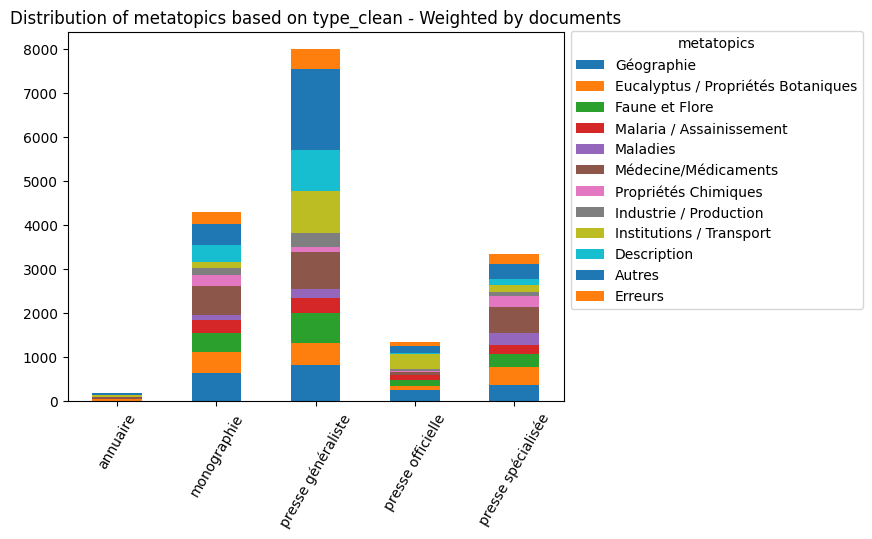

________________
comparision between: annuaire and monographie
p value is 7.231669038783796e-24
Dependent (reject H0)
________________
comparision between: annuaire and presse généraliste
p value is 1.293102701832139e-06
Dependent (reject H0)
________________
comparision between: annuaire and presse officielle
p value is 6.382565677997199e-14
Dependent (reject H0)
________________
comparision between: annuaire and presse spécialisée
p value is 2.4390531075121785e-16
Dependent (reject H0)
________________
comparision between: monographie and presse généraliste
p value is 1.0603814366862244e-185
Dependent (reject H0)
________________
comparision between: monographie and presse officielle
p value is 2.1291651453744238e-154
Dependent (reject H0)
________________
comparision between: monographie and presse spécialisée
p value is 1.5414799841568337e-43
Dependent (reject H0)
________________
comparision between: presse généraliste and presse officielle
p value is 4.666876139621558e-88
Depende

In [44]:
column_order = ['Géographie', 'Eucalyptus / Propriétés Botaniques', 'Faune et Flore', 'Malaria / Assainissement', 'Maladies', 'Médecine/Médicaments', 'Propriétés Chimiques', 'Industrie / Production', 'Institutions / Transport', 'Description', 'Autres', 'Erreurs']
plot_histogram(df, "type_clean", "metatopics", column_order=column_order)

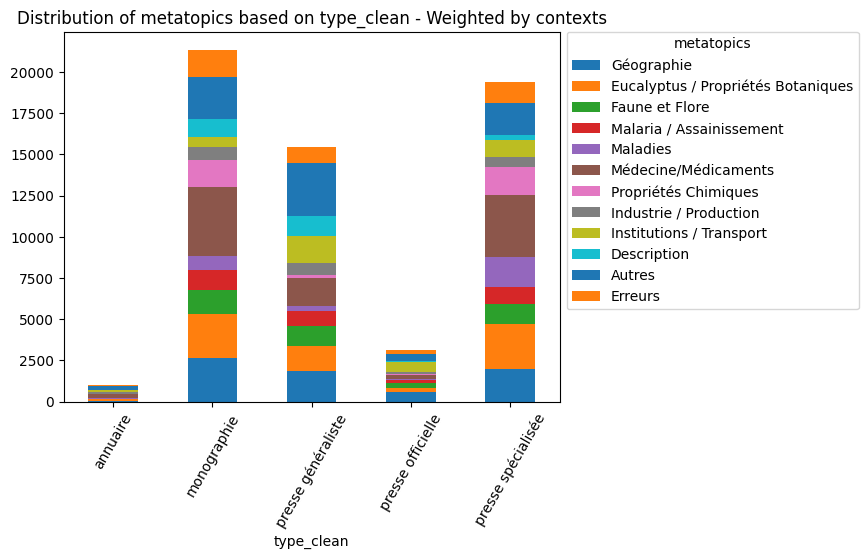

________________
comparision between: annuaire and monographie
p value is 9.882089708346395e-140
Dependent (reject H0)
________________
comparision between: annuaire and presse généraliste
p value is 5.557396889787488e-83
Dependent (reject H0)
________________
comparision between: annuaire and presse officielle
p value is 2.2447524709848184e-105
Dependent (reject H0)
________________
comparision between: annuaire and presse spécialisée
p value is 7.597231841877417e-133
Dependent (reject H0)
________________
comparision between: monographie and presse généraliste
p value is 0.0
Dependent (reject H0)
________________
comparision between: monographie and presse officielle
p value is 0.0
Dependent (reject H0)
________________
comparision between: monographie and presse spécialisée
p value is 4.902883169015482e-240
Dependent (reject H0)
________________
comparision between: presse généraliste and presse officielle
p value is 8.026928632640012e-113
Dependent (reject H0)
________________
comp

In [45]:
column_order = ['Géographie', 'Eucalyptus / Propriétés Botaniques', 'Faune et Flore', 'Malaria / Assainissement', 'Maladies', 'Médecine/Médicaments', 'Propriétés Chimiques', 'Industrie / Production', 'Institutions / Transport', 'Description', 'Autres', 'Erreurs']
distribution_df = plot_histogram(df, "type_clean", "metatopics", weights="context", column_order=column_order)

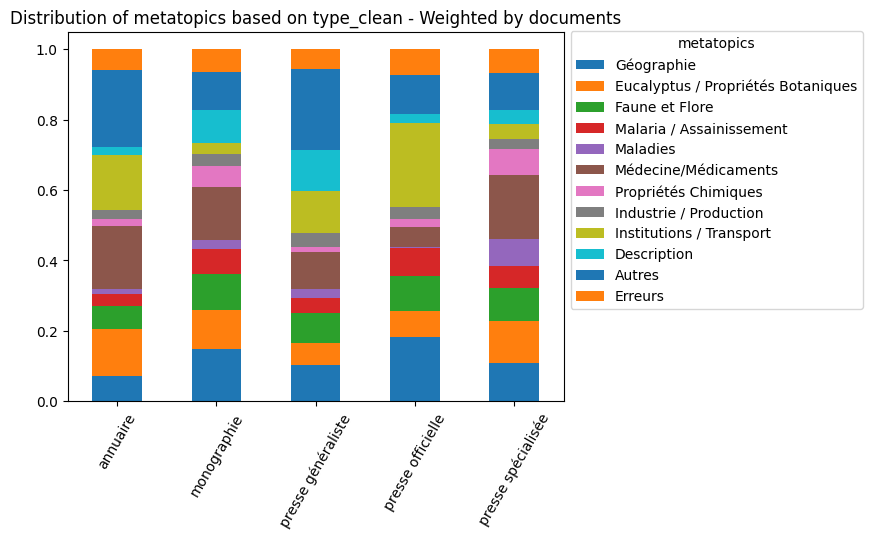

________________
comparision between: annuaire and monographie
p value is 0.9999999658719795
Independent (H0 holds true)
________________
comparision between: annuaire and presse généraliste
p value is 0.9999999990049866
Independent (H0 holds true)
________________
comparision between: annuaire and presse officielle
p value is 0.9999999861914436
Independent (H0 holds true)
________________
comparision between: annuaire and presse spécialisée
p value is 0.9999999849776482
Independent (H0 holds true)
________________
comparision between: monographie and presse généraliste
p value is 0.9999999965094186
Independent (H0 holds true)
________________
comparision between: monographie and presse officielle
p value is 0.9999999295225624
Independent (H0 holds true)
________________
comparision between: monographie and presse spécialisée
p value is 0.9999999999843543
Independent (H0 holds true)
________________
comparision between: presse généraliste and presse officielle
p value is 0.999999988507

In [46]:
column_order = ['Géographie', 'Eucalyptus / Propriétés Botaniques', 'Faune et Flore', 'Malaria / Assainissement', 'Maladies', 'Médecine/Médicaments', 'Propriétés Chimiques', 'Industrie / Production', 'Institutions / Transport', 'Description', "Autres", "Erreurs"]
distribution_df = plot_histogram(df, "type_clean", "metatopics", normalize=True, column_order=column_order)

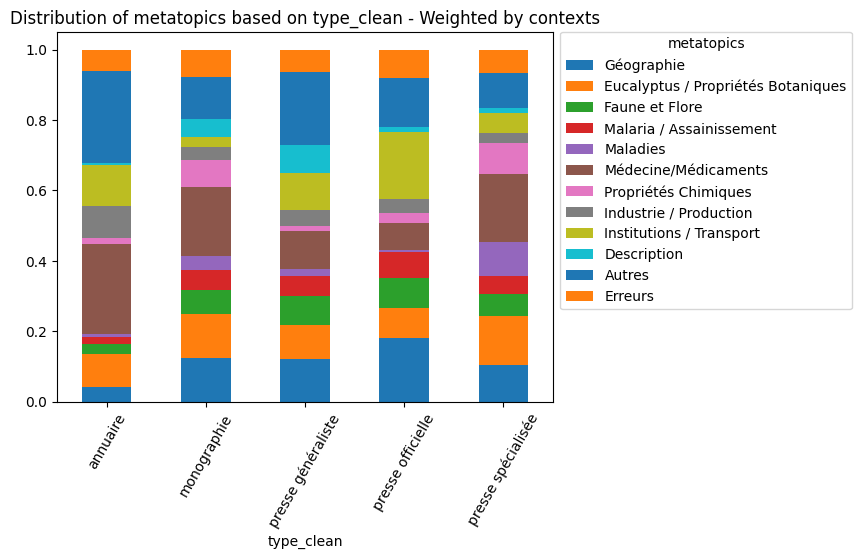

In [201]:
column_order = ['Géographie', 'Eucalyptus / Propriétés Botaniques', 'Faune et Flore', 'Malaria / Assainissement', 'Maladies', 'Médecine/Médicaments', 'Propriétés Chimiques', 'Industrie / Production', 'Institutions / Transport', 'Description', "Autres", "Erreurs"]
plot_histogram(df, "type_clean", "metatopics", weights="context", normalize=True, column_order=column_order)

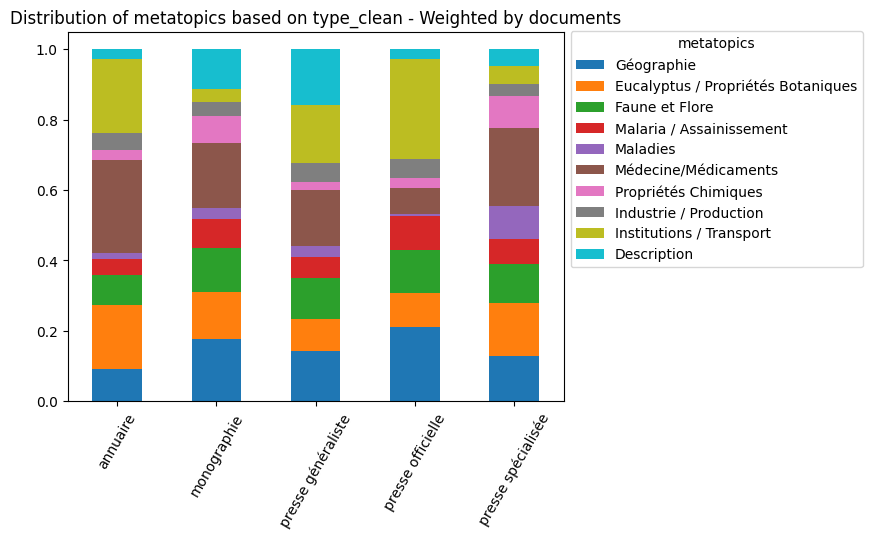

In [9]:
column_order = ['Géographie', 'Eucalyptus / Propriétés Botaniques', 'Faune et Flore', 'Malaria / Assainissement', 'Maladies', 'Médecine/Médicaments', 'Propriétés Chimiques', 'Industrie / Production', 'Institutions / Transport', 'Description']
distribution_df = plot_histogram(df, "type_clean", "metatopics", normalize=True, columns_to_remove=["Autres", "Erreurs"], column_order=column_order)

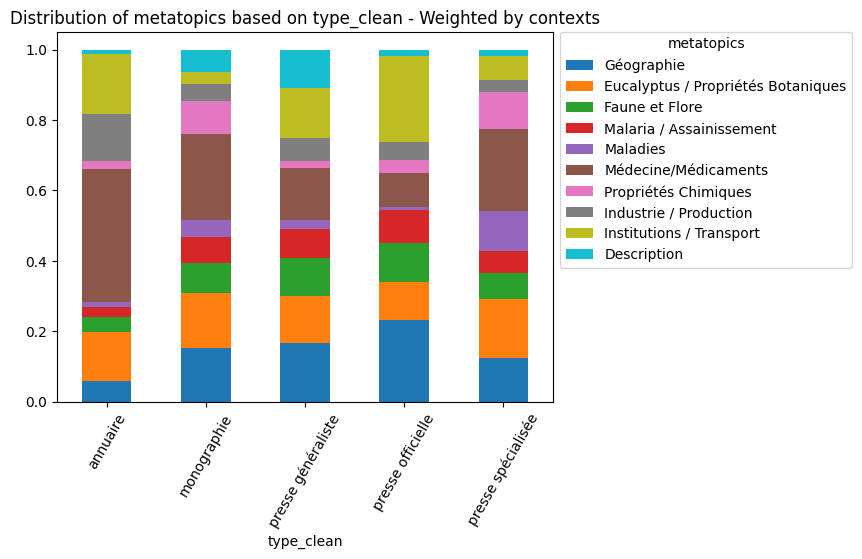

In [203]:
column_order = ['Géographie', 'Eucalyptus / Propriétés Botaniques', 'Faune et Flore', 'Malaria / Assainissement', 'Maladies', 'Médecine/Médicaments', 'Propriétés Chimiques', 'Industrie / Production', 'Institutions / Transport', 'Description']
plot_histogram(df, "type_clean", "metatopics", weights="context", normalize=True, columns_to_remove=["Autres", "Erreurs"], column_order=column_order)

## 2.3) Topics and time

In [ ]:
docs_year = [df.loc[df['ark'] == ark, "date_clean"].iloc[0] for ark in docs_ark]

In [ ]:
topics_over_time = topic_model.topics_over_time(docs_text, docs_year, nr_bins=60)

In [ ]:
topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=20)

<Axes: xlabel='date_clean'>

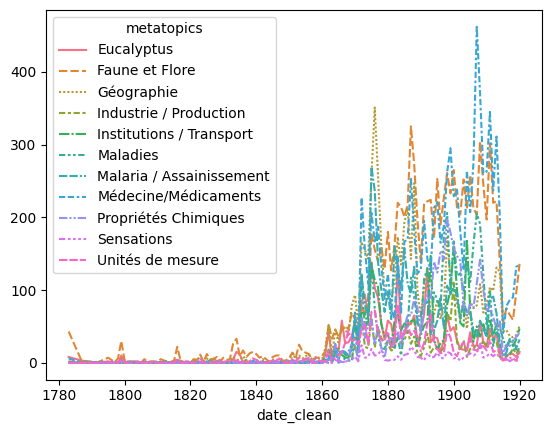

In [ ]:
exploded_df_metatopics = df.explode("metatopics").reset_index().drop("index", axis=1)
exploded_df_metatopics = exploded_df_metatopics[exploded_df_metatopics["metatopics"].isin(["Autres", "Erreurs"]) == False]
cross_tab_metatopics = pd.crosstab(exploded_df_metatopics.date_clean, exploded_df_metatopics.metatopics)
sns.lineplot(cross_tab_metatopics)

# 2.4) Topic co-occurrence network

In [31]:
G = nx.Graph()

In [33]:
# Create nodes
for metatopic, topics in metatopics.items():
    for topic in topics:
        G.add_node(topic, metatopic=metatopic, name=topic_model.get_topic_info()["Name"][topic + 1])

In [34]:
co_occurrences = df["topics"].to_list()
co_occurrences = [list(set(occ)) for occ in co_occurrences if len(set(occ)) > 1]
co_occurrences = [list(itertools.combinations(occ, 2)) for occ in co_occurrences]
co_occurrences = list(itertools.chain.from_iterable(co_occurrences))
co_occurrences = Counter(co_occurrences)
co_occurrences = [(occ[0][0], occ[0][1], occ[1]) for occ in co_occurrences.most_common()]

In [36]:
G.add_weighted_edges_from(co_occurrences)

In [37]:
nx.write_gexf(G, "test_network.gexf")

In [52]:
topic_number = 14
print(f"Topic: {topic_number}")
topic_model.get_topic(topic_number)

Topic: 14


[('froid', np.float64(0.30531993738656743)),
 ('degrés', np.float64(0.2874818770085894)),
 ('hiver', np.float64(0.28043155787704843)),
 ('température', np.float64(0.27531814868216975)),
 ('zéro', np.float64(0.26905654524169464)),
 ('froids', np.float64(0.2636410163344617)),
 ('supporté', np.float64(0.2136182075080532)),
 ('thermomètre', np.float64(0.20800506487939666)),
 ('hivers', np.float64(0.20458763429868682)),
 ('résisté', np.float64(0.19970649962814857))]

In [48]:
edges=sorted(G.edges(data=True), key=lambda edge: edge[2].get('weight', 1), reverse=True)
edges

[(0, 10, {'weight': 285}),
 (0, 23, {'weight': 207}),
 (3, 14, {'weight': 187}),
 (0, 14, {'weight': 167}),
 (10, 23, {'weight': 163}),
 (1, 14, {'weight': 162}),
 (8, 14, {'weight': 162}),
 (8, 23, {'weight': 160}),
 (2, 134, {'weight': 150}),
 (0, 39, {'weight': 147}),
 (1, 39, {'weight': 146}),
 (1, 23, {'weight': 146}),
 (0, 83, {'weight': 143}),
 (3, 23, {'weight': 142}),
 (2, 5, {'weight': 139}),
 (10, 14, {'weight': 136}),
 (2, 14, {'weight': 135}),
 (39, 3, {'weight': 134}),
 (2, 23, {'weight': 130}),
 (0, 51, {'weight': 121}),
 (83, 10, {'weight': 119}),
 (1, 15, {'weight': 114}),
 (0, 35, {'weight': 111}),
 (0, 102, {'weight': 110}),
 (39, 2, {'weight': 110}),
 (15, 8, {'weight': 110}),
 (83, 8, {'weight': 109}),
 (3, 15, {'weight': 109}),
 (8, 51, {'weight': 108}),
 (0, 7, {'weight': 107}),
 (1, 108, {'weight': 106}),
 (0, 15, {'weight': 103}),
 (0, 49, {'weight': 102}),
 (0, 26, {'weight': 101}),
 (2, 15, {'weight': 101}),
 (0, 126, {'weight': 100}),
 (3, 28, {'weight': 99}

## 2.5) Topics and place of publication:

In [10]:
# Aggregate places of publication per "zones" (Paris, France, Algeria, ...)
ile_de_france = ["Paris", "Étampes", "Meulan", "Épône", "Sceaux", "Vinciennes", "Verrières-le-Buisson", "Seine-et-Oise", "Villeneuve-la-Garenne", "Petit-Montrouge", "Vanves", "Fontainebleau", "Paris-Auteuil", "Argenteuil", "Levallois-Perret", "Saint-Germain-en-Laye", "Pontoise", "Lagny", "Coulommiers", "Mantes", "Saint-Denis", "Melun", "Meaux", "Neuilly-sur-Seine", "Versailles", "Puteaux", "Issy-les-Moulineaux"]
france_list = ["Reims", "Tours", "Lille", "Brest", "Orlèans", "Nancy", "Sens", "Rouen", "Dijon", "Arras", "Nantes", "Caen", "Sézanne", "Laval", "Auxerre", "Strasbourg", "Chalon-sur-Saône", "Angers", "Abbeville", "Épinal", "Le Havre", "Roubaix", "Rennes", "Nevers", "Draguignan", "Dunkerque", "Troyes", "St-Maixent",  "Autun", "Châteauroux", "Saint-Brieuc", "Bar-sur-Seine", "Les Andelys", "Le Mans", "Hâvre", "Avranches", "Poligny", "Clermont (Oise)", "Cambrai", "Langres", "Mulhouse", "Douai", "Colmar", "Saint-Quentin", "Bourges", "Besançon", "Bauvais", "Lorient", "Amiens", "Dieppe", "Compiègne", "Charolles", "Mâcon", "Quimperlé", "Mortagne", "Lunéville", "Valenciennes", "St.-Maixent", "Maubeuge", "Lamarche-sur-Saône", "Epinal", "Vendôme", "Chartres", "Redon", "Bar-le-Duc", "Issoudun", "Cherbourg", "Lons-le-Saunier", "Corbeil", "Châlons", "Guise", "Blois", "Alençon", "Billancourt", "Landerneau", "Châlons-sur-Marne", "Saint-Maixent", "Jallans", "Vannes", "La Flèche", "Montdidier", "Carentan", "Mundolsheim", "Saumur", "Morlaix", "Le Puy", "Cîteaux", "Falaise", "France", "Mamers", "Indre", "Seine", "Rochefort", "Calais", "Creil", "Joigny", "Laon", "Chagny", "Baugé", "Saint-Dizier", "Saint-Amand", "Semur", "Sedan", "Gien", "Saint-Dié", "Evreux", "Mesnil-sur-l'Estrée", "Soissons", "La Roche-sur-Yon", "Metz", "Montbéliard", "Boulogne-sur-Mer", "Cholet", "Coutances", "Yvetot", "Châlon-sur-Saône", "Nogent-le-Rotrou", "Creusot", "Belfort", "Villers-sous-Prény"]
france_sud_list = ["Tarbes", "Ajaccio", "Auch", "Mende", "Toulouse", "Hyères", "Bagnères", "Perpignan", "Montpellier", "Bastia", "Marseille", "Nice", "Apt", "Carcassonne", "Cannes", "Nîmes", "Toulon", "Marvejols", "Foix", "Cahors", "Albi", "Lodève", "Rodez", "Montauban", "Lavaur", "Castres", "Aix-en-Provence", "Orange", "Avignon", "Alais", "Vaucluse", "Figeac", "Saint-Gaudens", "Tournay", "Narbonne", "Bagnères-de-Bigorre", "Castelnaudary", "Digne", "Béziers", "Congénies", "Decazeville", "Antibes", "Langogne", "Nimes"]
nouvelle_aquitaine_list = ["Saint-Raphaël", "Bordeaux", "Limoges", "Pau", "Agen", "La Rochelle", "Libourne", "Orthez", "Poitiers", "Angoulême", "Tulle", "Montmorillon", "La Réole", "Bourg", "Périgeux", "Rochefort-sur-Mer", "Bazas", "Oloron", "Saintes", "Hendaye", "Mont-de-Marsan", "Mons", "Bayonne", "Niort", "Bergerac", "Châtellerault", "Saint-Priest-Taurion", "Brive", "Arcachon", "Cognac", "Biarritz", "Rochechouart"]
auvergne_rhone_alpes_list = ["Voiron", "Lyon", "Saint-Étienne", "Montélimar", "Grenoble", "Annecy", "Prades", "Oyonnax", "Moulins", "Bourg-en-Bresse", "Clermont-Ferrand", "Montbrison", "Privas", "Aurillac", "Valence-sur-Rhône", "Vichy", "Villedieu", "Séez", "Isère", "Vienne", "Gannat", "Monluçon", "Souvigny", "Annonay", "Commentry", "Roanne", "Vals-les-Bains", "Aix-les-Bains", "Chambéry", "Trévoux", "Brioude", "Saint-Flour", "Beauchastel"]

afrique_du_nord_list = ["Alger", "Sousse", "Rabat", "Casablanca", "Maroc", "Tunis", "Guelma", "Miliana", "Batna", "Mostaganem", "Oran", "Alger-Mustapha", "Blida", "Mustapha-Agha", "Bordj-Menaïel", "Constantine", "Mustapha-Alger", "Bougie", "Maison-Carrée", "Bône", "Sétif"]
madagascar_list = ["Tananarive", "Tamatave"]
europe_list = ["Bruxelles", "Anvers", "Coblenz", "Braine-le-Comte", "Namur", "Liège", "Göttingen", "Londres", "Leiden", "Amsterdam", "Philippeville", "Turin", "Charleville", "Neuchâtel", "Byzance", "Leipzig", "San Remo", "Barcelone", "Gand", "Harlem", "Zurich", "Madrid", "Berlin", "Milan", "Bâle", "Saint-Pétersbourg", "Copenhague", "Gemert", "Berne", "Genève", "Lausanne", "Salonique", "Lisbonne", "Neufchâtel", "Moscou", "Florence"]

asie_list = ["Saïgon", "Hanoï", "Pondichéry", "Papeete", "Maurice"]
antilles_list = ["Fort-de-France", "Basse-Terre", "Pointe-à-Pitre", "Port-de-France"]
reunion_list = ["Saint-Denis (Réunion)", "Saint-Pierre"]

docs_places = []
for _, row in df.iterrows():
    if row["publisher_place_clean"] in ile_de_france:
        docs_places.append("Paris / Île de France")
    elif row["publisher_place_clean"] in france_list:
        docs_places.append("France Métropolitaine")
    elif row["publisher_place_clean"] in france_sud_list:
        docs_places.append("Sud de la France")
    elif row["publisher_place_clean"] in auvergne_rhone_alpes_list:
        #docs_places.append("France Métropolitaine")
        docs_places.append("Sud de la France")
    elif row["publisher_place_clean"] in nouvelle_aquitaine_list:
        #docs_places.append("France Métropolitaine")
        docs_places.append("Sud de la France")
    elif row["publisher_place_clean"] in afrique_du_nord_list:
        docs_places.append("Afrique du Nord")
    elif row["publisher_place_clean"] in madagascar_list:
        docs_places.append("Madagascar")
    elif row["publisher_place_clean"] in europe_list:
        docs_places.append("Europe")
    else:
        docs_places.append("Autres")

df["publisher_place_country"] = docs_places

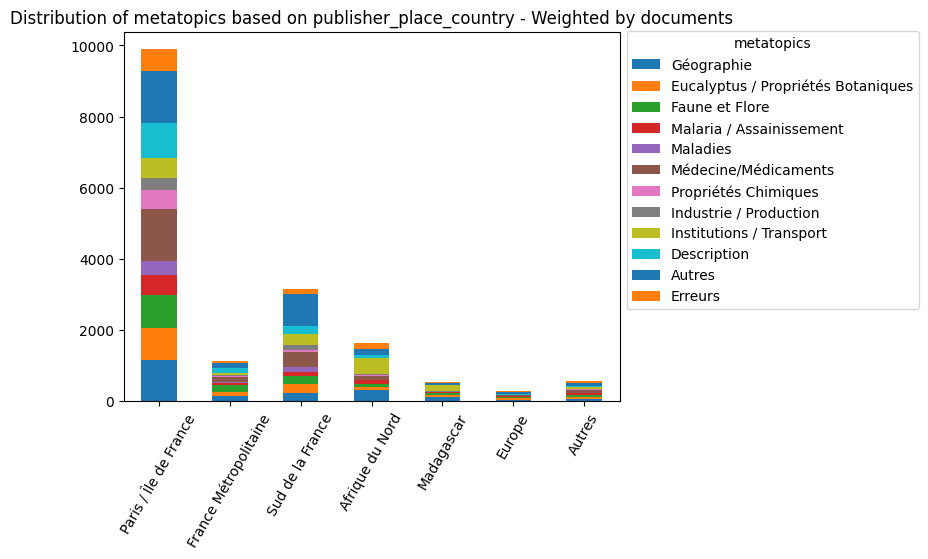

________________
comparision between: Paris / Île de France and France Métropolitaine
p value is 2.2141859619921042e-18
Dependent (reject H0)
________________
comparision between: Paris / Île de France and Sud de la France
p value is 3.860656947586624e-103
Dependent (reject H0)
________________
comparision between: Paris / Île de France and Afrique du Nord
p value is 9.151692348377587e-235
Dependent (reject H0)
________________
comparision between: Paris / Île de France and Madagascar
p value is 9.133319532775357e-175
Dependent (reject H0)
________________
comparision between: Paris / Île de France and Europe
p value is 1.0821244679314481e-08
Dependent (reject H0)
________________
comparision between: Paris / Île de France and Autres
p value is 2.319196535986171e-10
Dependent (reject H0)
________________
comparision between: France Métropolitaine and Sud de la France
p value is 9.680403958484805e-56
Dependent (reject H0)
________________
comparision between: France Métropolitaine and A

In [12]:
column_order = ['Géographie', 'Eucalyptus / Propriétés Botaniques', 'Faune et Flore', 'Malaria / Assainissement', 'Maladies', 'Médecine/Médicaments', 'Propriétés Chimiques', 'Industrie / Production', 'Institutions / Transport', 'Description', 'Autres', 'Erreurs']
row_order = ["Paris / Île de France", "France Métropolitaine", "Sud de la France", "Afrique du Nord", "Madagascar", "Europe", "Autres"]
plot_histogram(df, "publisher_place_country", "metatopics", column_order=column_order, row_order=row_order)

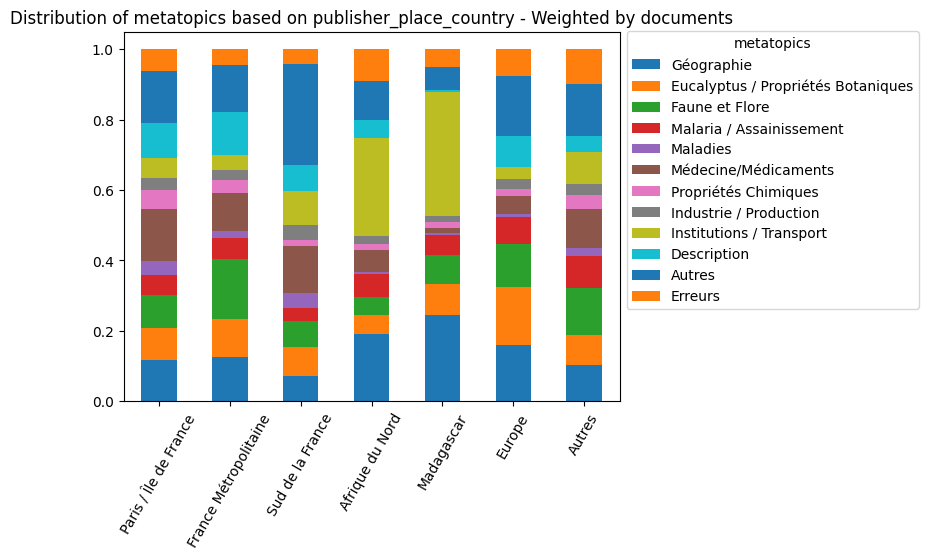

________________
comparision between: Paris / Île de France and France Métropolitaine
p value is 0.9999999999947407
Independent (H0 holds true)
________________
comparision between: Paris / Île de France and Sud de la France
p value is 0.9999999997125848
Independent (H0 holds true)
________________
comparision between: Paris / Île de France and Afrique du Nord
p value is 0.9999999220560336
Independent (H0 holds true)
________________
comparision between: Paris / Île de France and Madagascar
p value is 0.999998027110687
Independent (H0 holds true)
________________
comparision between: Paris / Île de France and Europe
p value is 0.9999999991899622
Independent (H0 holds true)
________________
comparision between: Paris / Île de France and Autres
p value is 0.9999999999803666
Independent (H0 holds true)
________________
comparision between: France Métropolitaine and Sud de la France
p value is 0.9999999957487221
Independent (H0 holds true)
________________
comparision between: France Métro

In [13]:
column_order = ['Géographie', 'Eucalyptus / Propriétés Botaniques', 'Faune et Flore', 'Malaria / Assainissement', 'Maladies', 'Médecine/Médicaments', 'Propriétés Chimiques', 'Industrie / Production', 'Institutions / Transport', 'Description', 'Autres', 'Erreurs']
row_order = ["Paris / Île de France", "France Métropolitaine", "Sud de la France", "Afrique du Nord", "Madagascar", "Europe", "Autres"]
plot_histogram(df, "publisher_place_country", "metatopics", normalize=True, column_order=column_order, row_order=row_order)

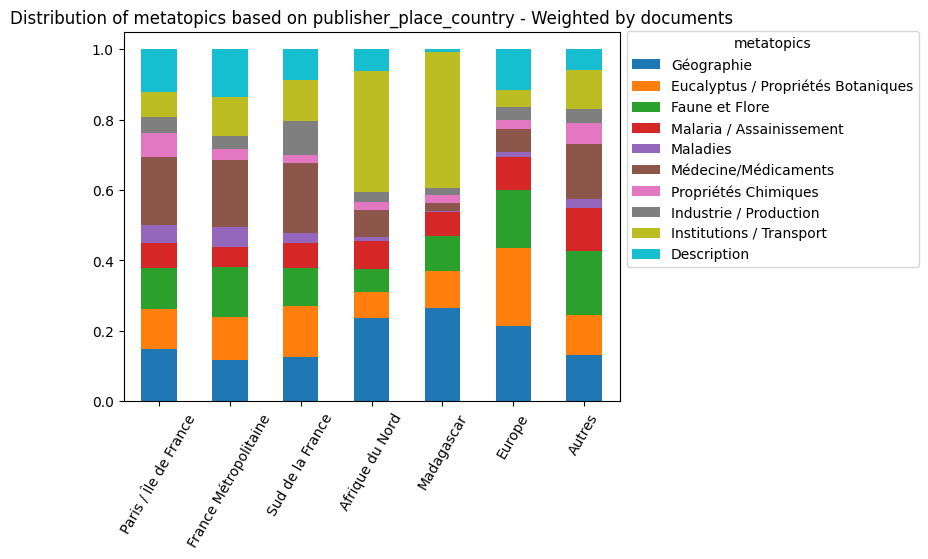

________________
comparision between: Paris / Île de France and France Métropolitaine
p value is 0.9999999998116256
Independent (H0 holds true)
________________
comparision between: Paris / Île de France and Sud de la France
p value is 0.9999999955130964
Independent (H0 holds true)
________________
comparision between: Paris / Île de France and Afrique du Nord
p value is 0.9999934533541679
Independent (H0 holds true)
________________
comparision between: Paris / Île de France and Madagascar
p value is 0.9999473527012291
Independent (H0 holds true)
________________
comparision between: Paris / Île de France and Europe
p value is 0.9999997509634675
Independent (H0 holds true)
________________
comparision between: Paris / Île de France and Autres
p value is 0.9999999942661353
Independent (H0 holds true)
________________
comparision between: France Métropolitaine and Sud de la France
p value is 0.999999997748936
Independent (H0 holds true)
________________
comparision between: France Métro

In [8]:
column_order = ['Géographie', 'Eucalyptus / Propriétés Botaniques', 'Faune et Flore', 'Malaria / Assainissement', 'Maladies', 'Médecine/Médicaments', 'Propriétés Chimiques', 'Industrie / Production', 'Institutions / Transport', 'Description']
row_order = ["Paris / Île de France", "France Métropolitaine", "Sud de la France", "Afrique du Nord", "Madagascar", "Europe", "Autres"]
plot_histogram(df, "publisher_place_country", "metatopics", normalize=True, columns_to_remove=["Erreurs", "Autres"], column_order=column_order, row_order=row_order)